In [5]:
import os
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

In [6]:
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

print(project_root)

C:\Users\SWEMa\Desktop\computer-vision-project-visionx


In [7]:
from utils.plate_detector import PlateDetector

In [8]:
model_path = project_root / "models" / "plate_detector" / "best.pt"
test_images_dir = project_root / "test_images"
output_dir = project_root / "outputs"

os.makedirs(output_dir, exist_ok=True)

print("Model:", model_path)
print("Images:", test_images_dir)
print("Outputs:", output_dir)

Model: C:\Users\SWEMa\Desktop\computer-vision-project-visionx\models\plate_detector\best.pt
Images: C:\Users\SWEMa\Desktop\computer-vision-project-visionx\test_images
Outputs: C:\Users\SWEMa\Desktop\computer-vision-project-visionx\outputs


In [9]:
detector = PlateDetector(
    model_path=str(model_path),
    conf=0.25,
    imgsz=960
)

In [10]:
image_files = [
    f for f in os.listdir(test_images_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of images:", len(image_files))
print(image_files)

Number of images: 5
['WhatsApp Image 2026-04-01 at 8.14.29 PM.jpeg', 'WhatsApp Image 2026-04-01 at 9.55.48 AM (1).jpeg', 'WhatsApp Image 2026-04-01 at 9.55.48 AM.jpeg', 'WhatsApp Image 2026-04-01 at 9.55.51 AM.jpeg', 'WhatsApp Image 2026-04-02 at 11.45.52 AM.jpeg']


Best detection: {'bbox': [556, 945, 647, 986], 'confidence': 0.8387898206710815, 'class_id': 0, 'class_name': 'license_plate'}


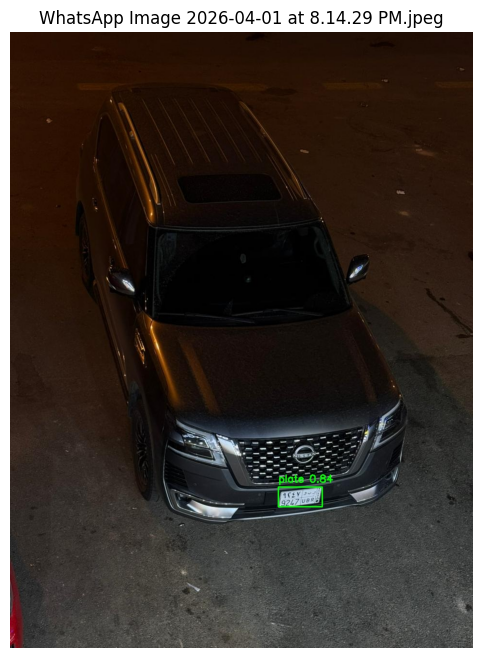

In [11]:
image_path = test_images_dir / image_files[4]
output_path = output_dir / f"det_{image_files[4]}"

best_detection = detector.detect_best(str(image_path))
print("Best detection:", best_detection)

detector.draw_detections(str(image_path), str(output_path))

img = cv2.imread(str(output_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title(image_files[0])
plt.axis("off")
plt.show()

In [2]:
import os
from pathlib import Path

project_root = Path("..").resolve()
print("Project root:", project_root)

for root, dirs, files in os.walk(project_root):
    image_files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if image_files:
        print("\nFolder:", root)
        for f in image_files:
            print(" -", f)

Project root: C:\Users\SWEMa\Desktop\computer-vision-project-visionx

Folder: C:\Users\SWEMa\Desktop\computer-vision-project-visionx\datasets\saudi-plates-dt.v1-ver1.yolov8\test\images
 - car_103_jpg.rf.7c9af3023760d861f25440e5f71f37fb.jpg
 - car_106_jpg.rf.8fe58a62d75387100f73b10a89aa1046.jpg
 - car_109_jpg.rf.8f173953c0d88b69f2b0fd7b0a4a22d7.jpg
 - car_112_jpg.rf.b17428d95d5fbc5848536ae480ff919c.jpg
 - car_115_jpg.rf.3d0d90d5142e8a7c66a3549948aa3c1e.jpg
 - car_116_jpg.rf.7667d231c35ba5211111226a523a2686.jpg
 - car_118_jpg.rf.bc9a51bd3bd37ea190177ff0e01129dc.jpg
 - car_123_jpg.rf.24b2a5f7f50ee5f1efb8093a19eb5799.jpg
 - car_127_jpg.rf.d4b7876b12a39d95704aadd086ac5e64.jpg
 - car_134_jpg.rf.89e884d826885e55726803b84edb9fc8.jpg
 - car_135_jpg.rf.f85e45f71ca7e01ca6860a45810fcd02.jpg
 - car_149_jpg.rf.82b2ac748fd4f61be9a70b24f327b643.jpg
 - car_150_jpg.rf.0794f5cbaec73c2669d45e11e51404ac.jpg
 - car_154_jpg.rf.377752c169cb772297acd84f7cee925f.jpg
 - car_156_jpg.rf.ebfd7eb44c6b1b7864c621156f9

In [3]:
image_path=str(project_root / "test_images" / "WhatsApp Image 2026-04-01 at 8.14.29 PM.jpeg")

{'bbox': [226, 862, 322, 925], 'confidence': 0.8409366607666016, 'crop_image': array([[[20, 10, 10],
        [20, 10, 10],
        [20, 10, 10],
        ...,
        [19, 10,  7],
        [22, 10, 10],
        [22,  9, 11]],

       [[18, 10, 10],
        [18, 10, 10],
        [18, 10, 10],
        ...,
        [22, 14, 14],
        [25, 14, 16],
        [24, 13, 15]],

       [[17, 11, 12],
        [17, 11, 12],
        [17, 11, 12],
        ...,
        [20, 14, 15],
        [23, 15, 16],
        [22, 14, 15]],

       ...,

       [[14,  9,  6],
        [14,  9,  6],
        [14,  9,  6],
        ...,
        [15, 10,  7],
        [15, 10,  7],
        [15, 10,  7]],

       [[25, 20, 17],
        [25, 20, 17],
        [25, 20, 17],
        ...,
        [31, 26, 23],
        [29, 24, 21],
        [29, 24, 21]],

       [[61, 54, 51],
        [61, 54, 51],
        [61, 54, 51],
        ...,
        [72, 65, 62],
        [73, 66, 63],
        [73, 66, 63]]], shape=(63, 96, 3), dtype=u

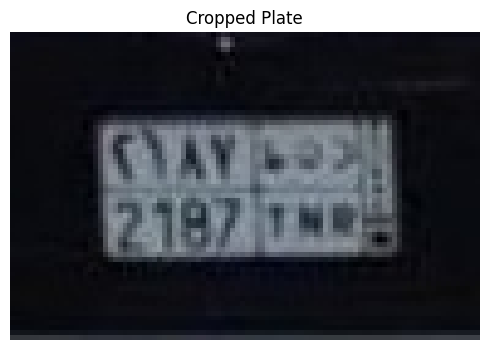

In [4]:
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

from utils.plate_cropper import PlateCropper

cropper = PlateCropper(
    detector_model_path=str(project_root / "models" / "plate_detector" / "best.pt"),
    conf=0.25,
    imgsz=960
)

result = cropper.crop_best_plate(
    image_path=str(project_root / "test_images" / "WhatsApp Image 2026-04-01 at 8.14.29 PM.jpeg"),
    save_path=str(project_root / "outputs" / "plate_crop.jpg"),
    padding=16
)

print(result)

img = cv2.imread(str(project_root / "outputs" / "plate_crop.jpg"))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.imshow(img)
plt.title("Cropped Plate")
plt.axis("off")
plt.show()

0 C:\Users\SWEMa\Desktop\computer-vision-project-visionx\datasets\saudi-plates-dt.v1-ver1.yolov8\test\images\car_103_jpg.rf.7c9af3023760d861f25440e5f71f37fb.jpg
1 C:\Users\SWEMa\Desktop\computer-vision-project-visionx\datasets\saudi-plates-dt.v1-ver1.yolov8\test\images\car_106_jpg.rf.8fe58a62d75387100f73b10a89aa1046.jpg
2 C:\Users\SWEMa\Desktop\computer-vision-project-visionx\datasets\saudi-plates-dt.v1-ver1.yolov8\test\images\car_109_jpg.rf.8f173953c0d88b69f2b0fd7b0a4a22d7.jpg
3 C:\Users\SWEMa\Desktop\computer-vision-project-visionx\datasets\saudi-plates-dt.v1-ver1.yolov8\test\images\car_112_jpg.rf.b17428d95d5fbc5848536ae480ff919c.jpg
4 C:\Users\SWEMa\Desktop\computer-vision-project-visionx\datasets\saudi-plates-dt.v1-ver1.yolov8\test\images\car_115_jpg.rf.3d0d90d5142e8a7c66a3549948aa3c1e.jpg
5 C:\Users\SWEMa\Desktop\computer-vision-project-visionx\datasets\saudi-plates-dt.v1-ver1.yolov8\test\images\car_116_jpg.rf.7667d231c35ba5211111226a523a2686.jpg
6 C:\Users\SWEMa\Desktop\computer-

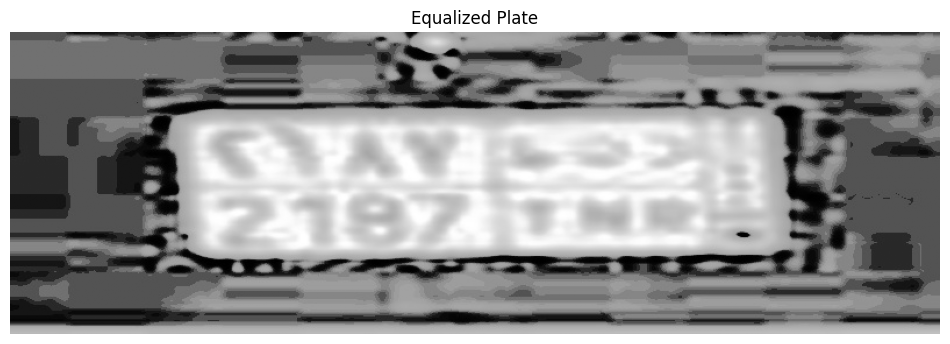

In [10]:
import os
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

from utils.plate_cropper import PlateCropper
from utils.plate_preprocess import PlatePreprocessor

all_images = []
for root, dirs, files in os.walk(project_root):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            all_images.append(Path(root) / f)

for i, p in enumerate(all_images):
    print(i, p)

image_path = str(all_images[872])  
print("Using image:", image_path)

cropper = PlateCropper(
    detector_model_path=str(project_root / "models" / "plate_detector" / "best.pt"),
    conf=0.25,
    imgsz=960
)

preprocessor = PlatePreprocessor(width=800, height=260)

crop_result = cropper.crop_best_plate(
    image_path=image_path,
    save_path=str(project_root / "outputs" / "plate_crop.jpg"),
    padding=16
)

print("Crop result:", crop_result)

processed_result = preprocessor.preprocess_equalized(
    plate_image=crop_result["crop_image"],
    save_path=str(project_root / "outputs" / "plate_equalized.jpg")
)

print("Processed result:", processed_result)

img = cv2.imread(str(project_root / "outputs" / "plate_equalized.jpg"), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 4))
plt.imshow(img, cmap="gray")
plt.title("Equalized Plate")
plt.axis("off")
plt.show()

In [15]:
!pip install ultralytics opencv-python pillow matplotlib accelerate


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
!pip install git+https://github.com/huggingface/transformers

  Cloning https://github.com/huggingface/transformers to C:\Users\SWEMa\AppData\Local\Temp\pip-req-build-byat2jw4
  Resolved https://github.com/huggingface/transformers to commit db9f18c370c92e971172e69bc9a88854947d9fc5
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for transformers: filename=transformers-5.6.0.dev0-py3-none-any.whl size=11353964 sha256=fa33d696385595862340978f658746f12aaf45bd051b32f752174bda5592482f
  Stored in directory: C:\Users\SWEMa\AppData\Local\Temp\pip-ephem-wheel-cache-fri7c4ee\wheels\2b\de\48\1c5b158806820c3979e1dc7a341b68dac1231f00b1a2c9442f
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.4.0
    

  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers 'C:\Users\SWEMa\AppData\Local\Temp\pip-req-build-byat2jw4'

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Cloning https://github.com/huggingface/transformers to C:\Users\SWEMa\AppData\Local\Temp\pip-req-build-vv4x59za
  Resolved https://github.com/huggingface/transformers to commit db9f18c370c92e971172e69bc9a88854947d9fc5
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers 'C:\Users\SWEMa\AppData\Local\Temp\pip-req-build-vv4x59za'

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:

import sys
import os

sys.path.append(os.path.abspath(".."))

import cv2
import matplotlib.pyplot as plt

from utils.plate_detector import PlateDetector
from utils.plate_enhancer import PlateEnhancer
from utils.plate_reader import PlateReader

In [2]:
def show_img(img, title="image", figsize=(8,4)):
    if img is None:
        print("Image is None")
        return

    plt.figure(figsize=figsize)

    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
    plt.show()

In [3]:
project_root = os.path.abspath("..")

image_path = os.path.join(
    project_root,
    "test_images",
    "WhatsApp Image 2026-04-01 at 8.14.29 PM.jpeg"
)

model_path = os.path.join(
    project_root,
    "models",
    "plate_detector",
    "best.pt"
)

output_dir = os.path.join(project_root, "outputs")
os.makedirs(output_dir, exist_ok=True)

print("image exists:", os.path.exists(image_path))
print("model exists:", os.path.exists(model_path))

detector = PlateDetector(model_path)
enhancer = PlateEnhancer(scale=3)
reader = PlateReader()

image exists: True
model exists: True


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.



0: 960x448 1 license_plate, 443.5ms
Speed: 49.6ms preprocess, 443.5ms inference, 20.2ms postprocess per image at shape (1, 3, 960, 448)


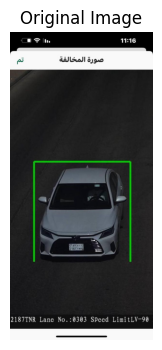

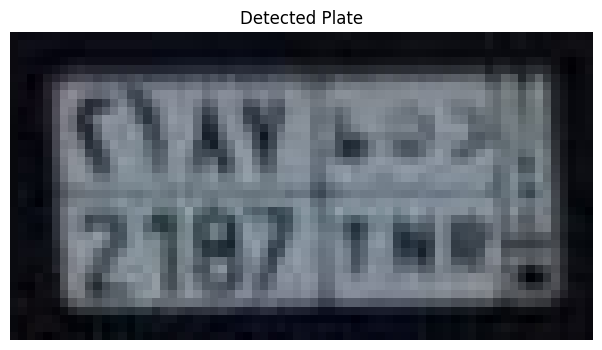

plate shape: (37, 70, 3)


In [4]:
original_img, plate = detector.detect_plate_with_padding(image_path)

show_img(original_img, "Original Image")

if plate is None:
    print("No plate detected")
else:
    show_img(plate, "Detected Plate")
    print("plate shape:", plate.shape)

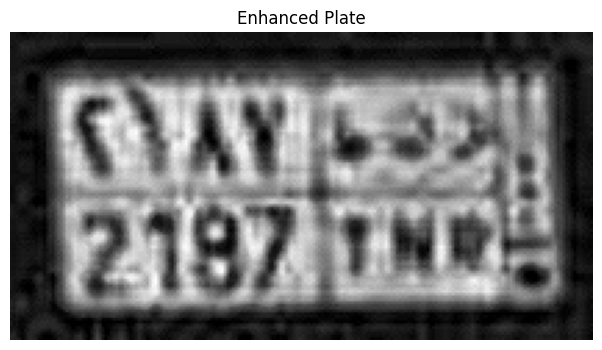

saved to: c:\Users\SWEMa\Desktop\computer-vision-project-visionx\outputs\enhanced_plate.png


In [5]:
enhanced = enhancer.enhance_plate_for_qwen(plate)

show_img(enhanced, "Enhanced Plate")

enhanced_path = os.path.join(output_dir, "enhanced_plate.png")
cv2.imwrite(enhanced_path, enhanced)

print("saved to:", enhanced_path)

In [6]:
result = reader.read_and_parse(enhanced_path)

print("RAW OUTPUT:")
print(result["raw"])
print()
print("DIGITS:", result["digits"])
print("LETTERS:", result["letters"])
print("FINAL:", result["final"])

RAW OUTPUT:
DIGITS: 2187
LETTERS: TNR
FINAL: 2187 TNR

DIGITS: 2187
LETTERS: TNR
FINAL: 2187 TNR
